## TOY MODEL (TO BE REPLACED/ADAPTED)

In [1]:
import numpy as np
import pymc as pm


# ----------------------------
# Toy data
# ----------------------------
rng = np.random.default_rng(123)

# Train data
n_train = 60
x_train = rng.uniform(-2, 2, size=n_train)

# True generative parameters (unknown to the model)
a_true, b_true, sigma_true = 0.7, -1.3, 0.5
y_train = a_true + b_true * x_train + rng.normal(0, sigma_true, size=n_train)

# Test data
n_test = 40
x_test = rng.uniform(-2, 2, size=n_test)
y_test = a_true + b_true * x_test + rng.normal(0, sigma_true, size=n_test)


# ----------------------------
# PyMC model (3 parameters: a, b, sigma)
# ----------------------------
with pm.Model() as model:
    a = pm.Normal("a", mu=0.0, sigma=2.0)
    b = pm.Normal("b", mu=0.0, sigma=2.0)
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    mu = a + b * x_train
    y = pm.Normal("y", mu=mu, sigma=sigma, observed=y_train)

    idata = pm.sample(1000, tune=1000, chains=2, target_accept=0.9, random_seed=123)

    # Posterior predictive for the TEST set:
    # Create a new RV for test predictions using the same parameters.
    mu_test = pm.Deterministic("mu_test", a + b * x_test)
    y_test_rv = pm.Normal("y_test", mu=mu_test, sigma=sigma)

    ppc = pm.sample_posterior_predictive(
        idata,
        var_names=["y_test"],
        random_seed=123
    )

# ppc.posterior_predictive["y_test"] typically has dims (chain, draw, n_test)
y_test_samples = ppc.posterior_predictive["y_test"].values


/home/paolo/.conda/envs/pymc_env/lib/python3.12/site-packages/numpy/_core/getlimits.py:552: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [a, b, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [y_test]


Output()

In [2]:
y_test

array([ 1.54239765,  2.4425765 ,  0.50960242,  0.53027185,  2.38103036,
        2.76578322,  0.78977548,  0.12276049,  1.36627274,  2.26165893,
       -1.35321972, -0.8225069 ,  3.32394219, -1.9948217 ,  3.75607331,
        2.47640761, -1.73747713,  3.61344517, -1.23956181,  3.57864981,
        2.12216929, -0.7484239 , -1.24961039,  0.52878348,  2.23719509,
        1.26061067,  3.76027794,  1.31996353, -0.2917654 ,  2.67927706,
        0.15627094, -1.17174284,  1.30080279,  1.7693213 , -1.43575098,
       -1.54334593,  2.51905729, -1.92463628,  2.01271421,  1.80425628])

In [5]:
y_test_samples

array([[[ 2.23298017,  2.56202119,  0.79425232, ..., -0.19151568,
          2.25040408,  2.68906581],
        [ 2.18437066,  1.97503773,  0.65529708, ..., -1.22857759,
          2.04008226,  3.28736323],
        [ 2.6916973 ,  2.89942758,  0.4423426 , ..., -2.12613349,
          2.10547826,  2.33459913],
        ...,
        [ 2.31794105,  2.84625732,  0.80626366, ..., -0.88867458,
          1.8257475 ,  3.33210922],
        [ 3.19644823,  2.85638064,  0.72410554, ..., -1.39278848,
          2.17701359,  2.29457257],
        [ 1.82637521,  2.91068768,  0.70206848, ..., -1.74853673,
          1.63182254,  2.72813028]],

       [[ 3.14111231,  2.21264448,  0.97786538, ..., -1.67445177,
          1.92445122,  2.38981293],
        [ 3.09713267,  2.56360759,  0.89735234, ..., -1.67200461,
          1.42206182,  2.55632881],
        [ 1.89787989,  2.82608828,  0.04251983, ..., -0.86179533,
          1.75631692,  2.7258304 ],
        ...,
        [ 2.32575124,  3.07310261,  0.20231643, ..., -

## Metric and plot

In [3]:

# ----------------------------
# Metric: W_alpha or Prediction Interval Coverage Probability (PICP)
# ----------------------------
def within_alpha(y_true, y_pred_samples, alpha: float, axis_draws=(0, 1)):
    """
    W_alpha: proportion of y_true inside the central alpha predictive interval.

    y_pred_samples shape examples:
      (chain, draw, n_obs)  -> axis_draws=(0,1)
      (draw, n_obs)         -> axis_draws=(0,)
    """
    y_true = np.asarray(y_true)

    if not (0.0 < alpha < 1.0):
        raise ValueError("alpha must be in (0, 1), e.g. 0.50 or 0.95. It represents a fraction!")

    q_low = (1.0 - alpha) / 2.0
    q_high = 1.0 - q_low

    lower = np.quantile(y_pred_samples, q_low, axis=axis_draws)
    upper = np.quantile(y_pred_samples, q_high, axis=axis_draws)

    inside = (y_true >= lower) & (y_true <= upper)
    return float(np.mean(inside)), lower, upper

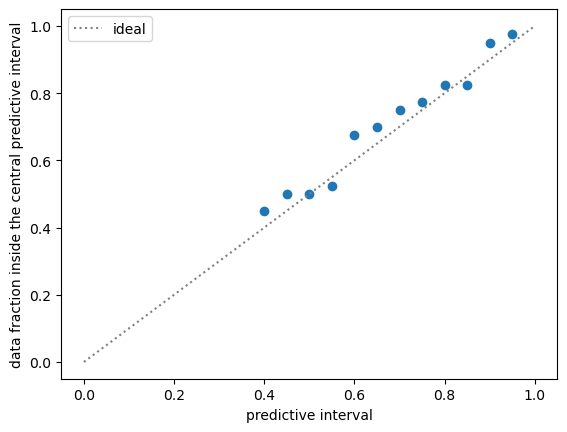

In [4]:
import matplotlib.pyplot as plt

walphas=[]
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, y_test_samples, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)


plt.scatter(alphas,walphas)
plt.ylabel('data fraction inside the central predictive interval')
plt.xlabel('predictive interval')
plt.plot([0,1],[0,1],linestyle=':',color='gray',label='ideal')
plt.legend()
plt.show()
